## Actividad 4 — Selección de variables
### Real Estate: ¿qué variables me quedo y cuáles quito?

La idea de esta actividad es tomar el notebook de selección de variables que vimos en clase y aplicarlo a un caso real: el dataset de Real Estate. Voy a revisar primero cómo se ven los datos, después meter todas las variables al modelo, ver cuáles están aportando y cuáles no, y al final quedarme con el modelo que mejor se comporte sin cargar variables de más.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

### 1. Los datos

El archivo trae una columna `No` que es solo un índice, así que la quito de una vez. Las columnas que sí importan son:

- **X1**: fecha de la transacción
- **X2**: antigüedad de la casa (años)
- **X3**: distancia a la estación de metro (MRT) más cercana
- **X4**: número de tiendas de conveniencia cerca
- **X5**: latitud
- **X6**: longitud
- **Y**: precio por unidad de área (lo que quiero predecir)

Les puse nombres más cortos para no estar escribiendo todo el tiempo "X1 transaction date".

In [5]:
df = pd.read_csv('Realestate (2).csv')
df = df.drop(columns=['No'])
df.columns = ['Fecha', 'Antiguedad', 'Distancia_MRT', 'Tiendas', 'Latitud', 'Longitud', 'Precio']

print(f"Forma del dataset: {df.shape}")
df.head()

Forma del dataset: (414, 7)


,Fecha,Antiguedad,Distancia_MRT,Tiendas,Latitud,Longitud,Precio
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:
df.describe().round(2)

,Fecha,Antiguedad,Distancia_MRT,Tiendas,Latitud,Longitud,Precio
count,414.00,414.00,414.00,414.00,414.00,414.00,414.00
mean,2013.15,17.71,1083.89,4.09,24.97,121.53,37.98
std,0.28,11.39,1262.11,2.95,0.01,0.02,13.61
min,2012.67,0.00,23.38,0.00,24.93,121.47,7.60
25%,2012.92,9.02,289.32,1.00,24.96,121.53,27.70
50%,2013.17,16.10,492.23,4.00,24.97,121.54,38.45
75%,2013.42,28.15,1454.28,6.00,24.98,121.54,46.60
max,2013.58,43.80,6488.02,10.00,25.01,121.57,117.50


No hay valores faltantes y las 414 observaciones se ven razonables. Ahora vamos a ver qué tan relacionada está cada variable con el precio, y qué tan relacionadas están entre ellas.

### 2. Correlaciones

Aquí busco dos cosas: qué variables se relacionan más con el precio (esas son las candidatas fuertes) y si hay variables muy correlacionadas entre sí (esas son un foco rojo de multicolinealidad).

In [7]:
print(df.corr().round(3))

               Fecha  Antiguedad  Distancia_MRT  Tiendas  Latitud  Longitud  \
Fecha          1.000       0.018          0.061    0.010    0.035    -0.041   
Antiguedad     0.018       1.000          0.026    0.050    0.054    -0.049   
Distancia_MRT  0.061       0.026          1.000   -0.603   -0.591    -0.806   
Tiendas        0.010       0.050         -0.603    1.000    0.444     0.449   
Latitud        0.035       0.054         -0.591    0.444    1.000     0.413   
Longitud      -0.041      -0.049         -0.806    0.449    0.413     1.000   
Precio         0.087      -0.211         -0.674    0.571    0.546     0.523   

               Precio  
Fecha           0.087  
Antiguedad     -0.211  
Distancia_MRT  -0.674  
Tiendas         0.571  
Latitud         0.546  
Longitud        0.523  
Precio          1.000  


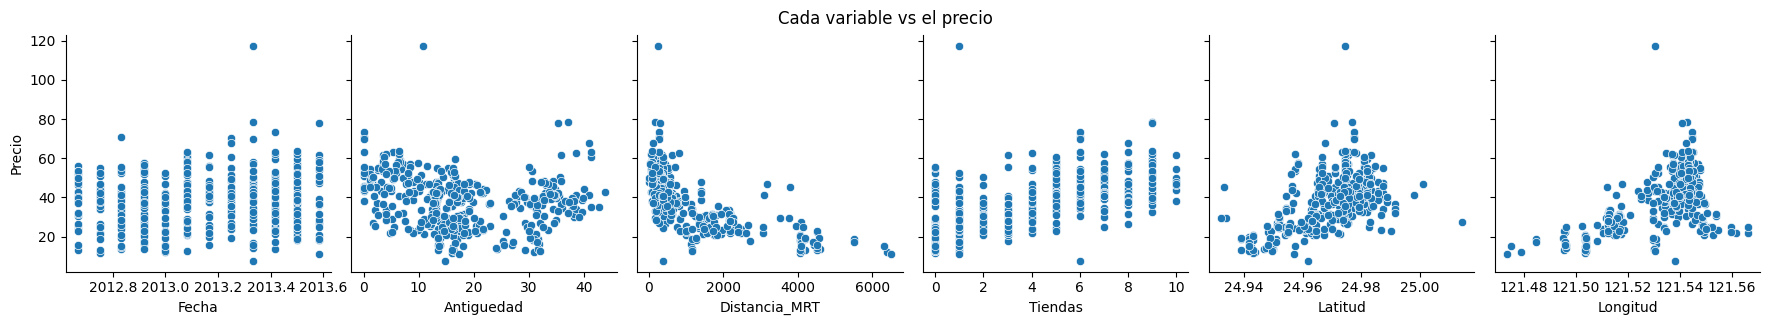

In [8]:
sns.pairplot(df, y_vars=['Precio'], x_vars=['Fecha','Antiguedad','Distancia_MRT','Tiendas','Latitud','Longitud'], height=3)
plt.suptitle('Cada variable vs el precio', y=1.05)
plt.show()

Lo que salta a la vista:

- **Distancia_MRT** tiene la correlación más fuerte con el precio (negativa, como se esperaría: mientras más lejos del metro, más barata la casa).
- **Tiendas**, **Latitud** y **Longitud** también se mueven bastante con el precio.
- **Antiguedad** tiene una relación negativa pero débil.
- **Fecha** casi no se mueve con el precio, su correlación es prácticamente cero. Esa puedeser candidata a salir del modelo.

Y entre las predictoras, **Latitud** y **Longitud** están correlacionadas entre sí (ambas describen ubicación), así que puede que una de las dos esté sobrando.

### 3. Modelo con todas las variables

Antes de quitar nada, meto todo al modelo para ver cómo se comporta y qué tan significativo sale cada coeficiente.

In [10]:
X = df.drop('Precio', axis=1)
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo_completo = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     66.58
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.26e-51
Time:                        19:27:38   Log-Likelihood:                -1041.9
No. Observations:                 289   AIC:                             2098.
Df Residuals:                     282   BIC:                             2124.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.135e+04   8527.829     -1.331

El modelo completo el R² anda en 0.58. Lo interesante está en la columna de p-valores: **Longitud** sale con un p-valor de 0.8, muy por arriba de 0.05, así que estadísticamente no está aportando nada una vez que ya tengo Latitud, Tiendas, Distancia_MRT, etc. en el modelo. El resto de las variables sí se ven significativas, incluyendo Fecha (p = 0.001), lo cual me sorprendió un poco porque su correlación simple con el precio era casi nula — pero en presencia de las otras variables sí termina aportando algo.

### 4. Revisando multicolinealidad con VIF

Antes de decidir qué quitar, calculo el VIF de cada variable para confirmar si Latitud y Longitud de plano se están pisando entre sí.

In [11]:
X_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data)

        Variable       VIF
0          const  1.000000
1          Fecha  1.014674
2     Antiguedad  1.014287
3  Distancia_MRT  4.323019
4        Tiendas  1.617038
5        Latitud  1.610234
6       Longitud  2.926302


Ninguna variable pasa de VIF = 5, así que no hay multicolinealidad severa. Longitud es la que tiene el VIF más alto (cerca de 3) pero no es alarmante por sí solo. El problema de longitud no es que esté duplicando información de forma extrema, es que simplemente no explica nada adicional del precio que latitud y las demás no expliquen ya.

### 5. Selección hacia adelante (forward)

Uso la misma función de selección hacia adelante del notebook de clase, basada en el p-valor de cada variable, para dejar que el propio proceso decida qué se queda.

In [12]:
def forward_selection(X, y, threshold=0.05):
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)

        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]

        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

        if not changed:
            break

    return included

variables_seleccionadas = forward_selection(X_train, y_train)
print(f"Variables seleccionadas: {variables_seleccionadas}")

Variables seleccionadas: ['Distancia_MRT', 'Latitud', 'Antiguedad', 'Tiendas', 'Fecha']


Tal como sospechaba desde las correlaciones y el p-valor del modelo completo: el forward selection deja fuera a **Longitud** y se queda con las otras cinco variables (Fecha, Antigüedad, Distancia_MRT, Tiendas y Latitud).

### 6. Comparando modelos

Ahora comparo el modelo completo contra el modelo sin Longitud, usando R², R² ajustado y AIC. Si el modelo reducido no pierde nada de poder explicativo pero es más simple, esa es la señal de que longitud de verdad estaba de más.

In [13]:
combinaciones = [
    list(X.columns),
    variables_seleccionadas,
]

nombres = [
    'Modelo completo (6 variables)',
    'Modelo sin Longitud (5 variables)',
]

for nombre, vars_list in zip(nombres, combinaciones):
    X_sel = sm.add_constant(X[vars_list])
    modelo = sm.OLS(y, X_sel).fit()
    print(f"{nombre}")
    print(f"  Variables: {vars_list}")
    print(f"  R² = {modelo.rsquared:.4f}")
    print(f"  R² ajustado = {modelo.rsquared_adj:.4f}")
    print(f"  AIC = {modelo.aic:.2f}")
    print(f"  BIC = {modelo.bic:.2f}")
    print()

Modelo completo (6 variables)
  Variables: ['Fecha', 'Antiguedad', 'Distancia_MRT', 'Tiendas', 'Latitud', 'Longitud']
  R² = 0.5824
  R² ajustado = 0.5762
  AIC = 2987.92
  BIC = 3016.11

Modelo sin Longitud (5 variables)
  Variables: ['Distancia_MRT', 'Latitud', 'Antiguedad', 'Tiendas', 'Fecha']
  R² = 0.5823
  R² ajustado = 0.5772
  AIC = 2985.99
  BIC = 3010.15



El R² prácticamente no cambia (0.5824 vs 0.5823, la diferencia es ruido), pero el R² ajustado en realidad sube un poquito al quitar longitud, y tanto el AIC como el BIC bajan. Eso es justo lo que se espera cuando una variable no está aportando: el modelo se vuelve un poco más simple sin perder capacidad de explicar el precio.

### 7. Comparando desempeño real en datos de prueba

Los criterios de arriba usan todo el dataset para ajustar. Para tener una comparación más honesta separo entrenamiento y prueba, y veo qué tan bien predice cada modelo en datos que no vio.

In [14]:
modelo_full = LinearRegression()
modelo_full.fit(X_train, y_train)
y_pred_full = modelo_full.predict(X_test)

X_train_sel = X_train[variables_seleccionadas]
X_test_sel = X_test[variables_seleccionadas]

modelo_sel = LinearRegression()
modelo_sel.fit(X_train_sel, y_train)
y_pred_sel = modelo_sel.predict(X_test_sel)

for nombre, y_pred in [('Modelo completo', y_pred_full), ('Modelo sin Longitud', y_pred_sel)]:
    mae = metrics.mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"{nombre}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R²   = {r2:.4f}")
    print()

Modelo completo
  MAE  = 6.1848
  RMSE = 8.5772
  R²   = 0.5601

Modelo sin Longitud
  MAE  = 6.1424
  RMSE = 8.5266
  R²   = 0.5652



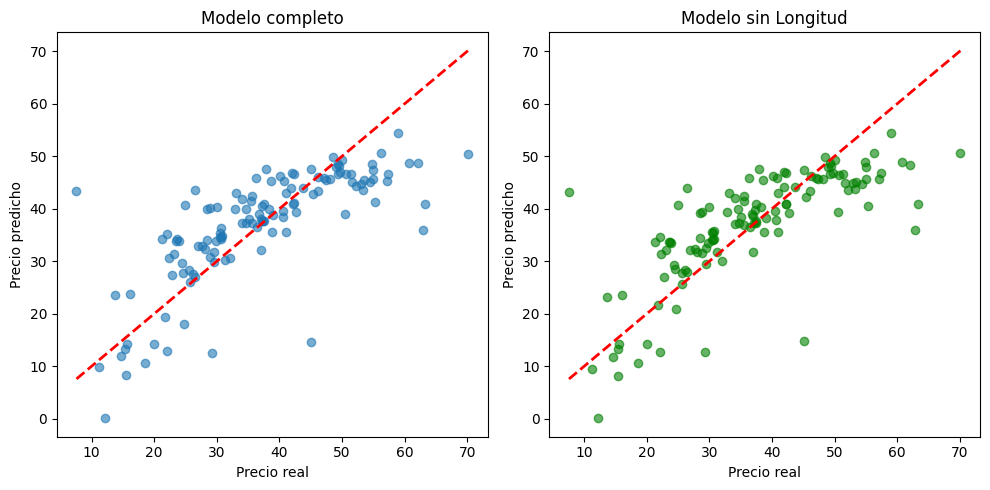

In [15]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_full, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Modelo completo')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sel, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Modelo sin Longitud')

plt.tight_layout()
plt.show()

El modelo sin Longitud da un RMSE un poco menor que el completo, y el R² en prueba también sale ligeramente mejor. No es una diferencia enorme, pero confirma la misma historia: quitar mlongitud no le cuesta nada al modelo, y de hecho ayuda un poquito porque deja de meter ruido innecesario.

### 8. Conclusión

Después de revisar correlaciones, VIF, p-valores del modelo completo y la selección hacia adelante, la variable que sobra es **longitud**. Todas las demás (Fecha, Antigüedad, Distancia al MRT, número de Tiendas y Latitud) resultan significativas y se quedan en el modelo final:

$$\text{Precio} = \beta_0 + \beta_1 \cdot \text{Fecha} + \beta_2 \cdot \text{Antigüedad} + \beta_3 \cdot \text{Distancia\_MRT} + \beta_4 \cdot \text{Tiendas} + \beta_5 \cdot \text{Latitud} + \varepsilon$$

Tiene sentido que longitud no aportara mucho: junto con latitud describe la ubicación, y ambas están correlacionadas entre sí, así que gran parte de lo que longitud podría explicar ya lo está cubriendo latitud (que además tiene una relación más fuerte con el precio). Quitar una variable redundante no solo simplifica el modelo, sino que en este caso incluso mejoró un poco el desempeño al predecir sobre datos nuevos.